Notebook for illustrating the optimizations done in the gradient computation on the restricted state space.

In [1]:
import mhn
from mhn.optimizers import Optimizer, Device
import pandas as pd
import time
import matplotlib.pyplot as plt
import math
import numpy as np

np.random.seed(123)


c:\Users\michi\Uni\SHK_Spang\learnmhn_state-space-optimization\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


For performance evaluation we are interested in whether CUDA optimizations are available on our machine

In [2]:
mhn.CUDA_AVAILABLE

'CUDA is available'

In [3]:
opt = Optimizer()
opt.set_penalty(opt.Penalty.L1)
opt.set_device(Device.CPU)

In [4]:
input = pd.read_csv('LUAD_n12.csv')

C:\Users\michi\Uni\SHK_Spang\learnmhn_state-space-optimization\mhn\optimizers.py:287: UserWarning: The dtype of the given data matrix is changed to np.int32
  warnings.warn(


[477, 235, 349, 201, 349, 408, 1, 1, 28, 28, 76, 24, 1, 2, 31, 15, 68, 18, 76, 29, 2, 2, 3, 16, 5, 32, 21, 9, 4, 37, 22, 48, 10, 1, 2, 4, 1, 4, 9, 1, 1, 10, 8, 51, 9, 7, 5, 1, 3, 3, 20, 1, 4, 17, 4, 4, 2, 1, 1, 2, 7, 2, 1, 1, 2, 4, 21, 6, 8, 9, 12, 5, 6, 6, 1, 1, 3, 2, 2, 6, 5, 10, 1, 5, 3, 24, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 8, 18, 16, 20, 4, 10, 1, 3, 5, 5, 2, 1, 1, 3, 7, 4, 1, 3, 1, 6, 3, 1, 1, 3, 4, 1, 1, 1, 3, 2, 1, 1, 3, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 18, 41, 11, 13, 3, 2, 2, 2, 1, 1, 8, 5, 2, 1, 1, 2, 3, 1, 7, 4, 2, 1, 1, 3, 1, 2, 1, 1, 3, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 5, 2, 2, 1, 3, 1, 3, 1, 2, 1, 1, 2, 1, 1, 1, 5, 13, 18, 13, 32, 23, 1, 1, 1, 5, 4, 3, 3, 5, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 44, 30, 3, 9, 3, 3, 7, 4, 1, 1, 2, 2, 2, 1, 3, 2, 4, 2, 1, 1, 1, 1, 1, 5, 1, 3, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 3, 1, 1, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1]
3662
0 / 3662 are redundant samp

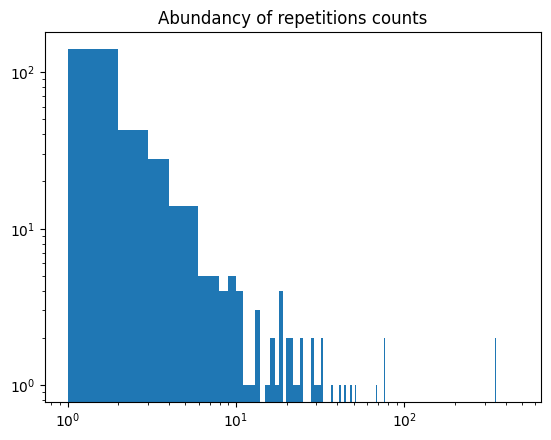

In [5]:
my_data = np.tile(input, (1,1))
opt.load_data_matrix(my_data, reduce_data_redundancies=True)
data_retrieval, repetitions=opt._data.get_data_repetitions()
print(repetitions)
print(sum(repetitions))
print(f"{sum([1 if r==0 else 0 for r in repetitions])} / {len(my_data)} are redundant samples")
plt.hist([r for r in repetitions if r!=0], bins=max(repetitions),)
plt.yscale('log')
plt.xscale('log')
plt.title("Abundancy of repetitions counts")
plt.show()

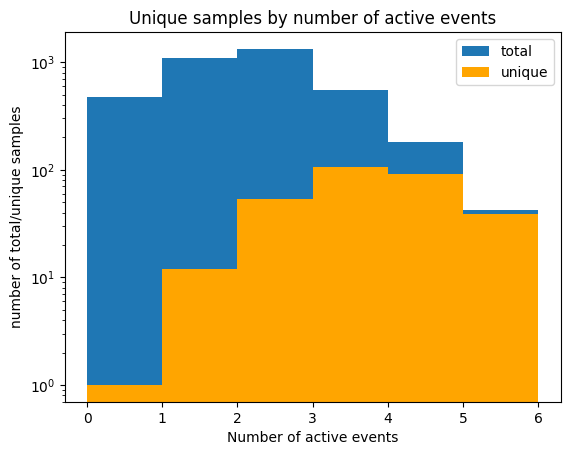

In [24]:
active_events_count = [sum(s) for s in my_data]
compr_active_events_count = [sum(s) for s in data_retrieval]

plt.hist(active_events_count,bins=range(7), label="total")
plt.hist(compr_active_events_count, bins=range(7), color='orange', label="unique")
plt.title("Unique samples by number of active events")
plt.ylabel("number of total/unique samples")
plt.xlabel("Number of active events")
plt.yscale('log')
plt.legend()

Text(0.5, 0, 'Number of active events')

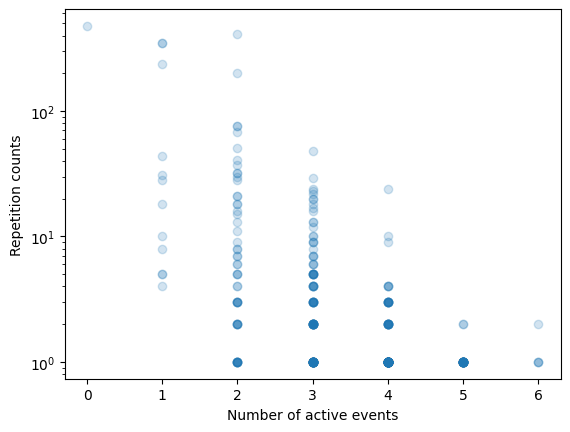

In [22]:
plt.scatter(compr_active_events_count, repetitions, alpha=0.2)
plt.yscale('log')
plt.ylabel("Repetition counts")
plt.xlabel("Number of active events")

In [9]:
#test code
opt._data.compress_data()
compr_data, compr_repetitions = opt._data.get_data_repetitions()
print(repetitions)
print(compr_repetitions)
print(f"{len(compr_repetitions)} unique samples")

[477, 235, 349, 201, 349, 408, 1, 1, 28, 28, 76, 24, 1, 2, 31, 15, 68, 18, 76, 29, 2, 2, 3, 16, 5, 32, 21, 9, 4, 37, 22, 48, 10, 1, 2, 4, 1, 4, 9, 1, 1, 10, 8, 51, 9, 7, 5, 1, 3, 3, 20, 1, 4, 17, 4, 4, 2, 1, 1, 2, 7, 2, 1, 1, 2, 4, 21, 6, 8, 9, 12, 5, 6, 6, 1, 1, 3, 2, 2, 6, 5, 10, 1, 5, 3, 24, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 8, 18, 16, 20, 4, 10, 1, 3, 5, 5, 2, 1, 1, 3, 7, 4, 1, 3, 1, 6, 3, 1, 1, 3, 4, 1, 1, 1, 3, 2, 1, 1, 3, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 18, 41, 11, 13, 3, 2, 2, 2, 1, 1, 8, 5, 2, 1, 1, 2, 3, 1, 7, 4, 2, 1, 1, 3, 1, 2, 1, 1, 3, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 5, 2, 2, 1, 3, 1, 3, 1, 2, 1, 1, 2, 1, 1, 1, 5, 13, 18, 13, 32, 23, 1, 1, 1, 5, 4, 3, 3, 5, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 44, 30, 3, 9, 3, 3, 7, 4, 1, 1, 2, 2, 2, 1, 3, 2, 4, 2, 1, 1, 1, 1, 1, 5, 1, 3, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 3, 1, 1, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1]
[477, 235, 349, 201, 349, 408, 1

In [ ]:
print(opt._data.get_max_mutation_num())

6


In [ ]:
opt.train(5/len(input))

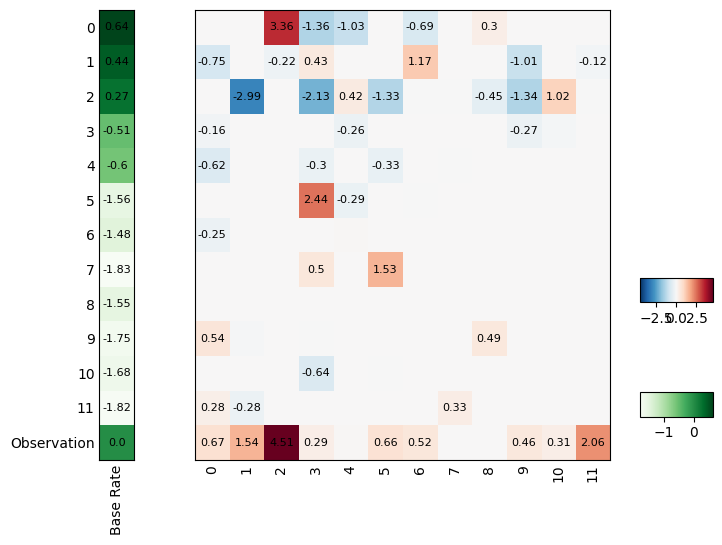

In [ ]:
opt.result.plot()
plt.show()

In [ ]:
dataset_fractions = [0.1, 0.25, 0.5, 0.75, 1, 1.5, 2, 3, 4, 5, 6, 7, 8, 9]
N=len(input)
computation_speeds={frac:[] for frac in dataset_fractions}
max_it = 200

repetitions=3
for i in range(repetitions):
    for dataset_fraction in dataset_fractions:
        input_subset = np.tile(input, (math.ceil(dataset_fraction),1))[:int(N*dataset_fraction)]
        

        #input_subset = input.sample(frac=dataset_fraction, replace=True, random_state=6)
        start_prep = time.process_time()
        opt.load_data_matrix(input_subset)
        opt._data.compress_data()
        end_prep = time.process_time()


        print(f"{dataset_fraction} fraction of dataset ({len(input_subset)}) ")

        #measure time optimization takes
        start = time.process_time()
    
        opt.train(maxit=max_it)      
        end = time.process_time()

        time_elapsed= end-start
        computation_speeds[dataset_fraction].append(time_elapsed)
        print(f"Preparation time: {end_prep-start_prep}\t CPU time: {time_elapsed} seconds")

C:\Users\michi\Uni\SHK_Spang\learnmhn_state-space-optimization\mhn\optimizers.py:287: UserWarning: The dtype of the given data matrix is changed to np.int32
  warnings.warn(


0.1 fraction of dataset (366) 
Preparation time: 0.0	 CPU time: 0.71875 seconds
0.25 fraction of dataset (915) 
Preparation time: 0.0	 CPU time: 1.15625 seconds
0.5 fraction of dataset (1831) 
Preparation time: 0.0	 CPU time: 1.5 seconds
0.75 fraction of dataset (2746) 
Preparation time: 0.0	 CPU time: 1.65625 seconds
1 fraction of dataset (3662) 
Preparation time: 0.0	 CPU time: 1.78125 seconds
1.5 fraction of dataset (5493) 
Preparation time: 0.0	 CPU time: 1.796875 seconds
2 fraction of dataset (7324) 
Preparation time: 0.015625	 CPU time: 1.796875 seconds
3 fraction of dataset (10986) 
Preparation time: 0.0	 CPU time: 1.875 seconds
4 fraction of dataset (14648) 
Preparation time: 0.015625	 CPU time: 1.71875 seconds
5 fraction of dataset (18310) 
Preparation time: 0.015625	 CPU time: 1.6875 seconds
6 fraction of dataset (21972) 
Preparation time: 0.03125	 CPU time: 1.703125 seconds
7 fraction of dataset (25634) 
Preparation time: 0.03125	 CPU time: 1.640625 seconds
8 fraction of dat

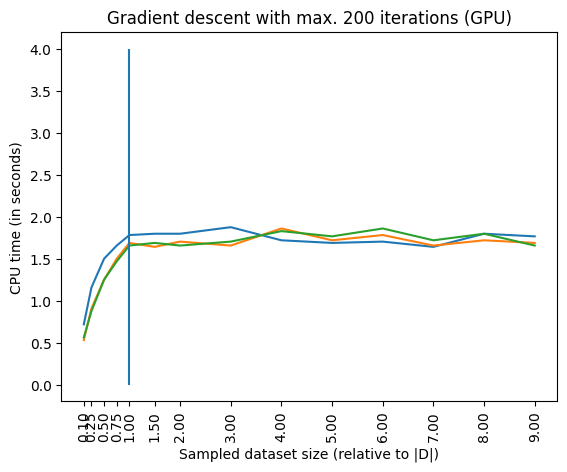

In [ ]:
comp_speeds_df=pd.DataFrame.from_dict(computation_speeds)
comp_speeds_df.T.plot(xlabel="Sampled dataset size (relative to |D|)", ylabel="CPU time (in seconds)", xticks=dataset_fractions, legend=False)
plt.xticks(rotation=90)
plt.title(f"Gradient descent with max. {max_it} iterations (GPU)")

plt.vlines(1,0,4)

In [ ]:


dataset_fractions = [0.1, 0.25, 0.5, 0.75, 1, 1.5, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
N=len(input)
computation_times={frac:[] for frac in dataset_fractions}

repetitions=3
for i in range(repetitions):
    for dataset_fraction in dataset_fractions:
        input_subset = np.tile(input, (math.ceil(dataset_fraction),1))[:int(N*dataset_fraction)]
        

        #input_subset = input.sample(frac=dataset_fraction, replace=True, random_state=6)
        start_prep = time.process_time()
        opt.load_data_matrix(input_subset)
        opt._data.compress_data()
        end_prep = time.process_time()


        print(f"{dataset_fraction} fraction of dataset ({len(input_subset)}) ")

        #measure time optimization takes
        start = time.process_time()
        
        my_lam = 1.0/len(input_subset)
        if dataset_fraction > 1:
            my_lam = 1.0/N  # fix one value for lambda to have comparable score landscapes (for "full" datasets)
        opt.train(lam = my_lam)      
        end = time.process_time()

        time_elapsed= end-start
        computation_times[dataset_fraction].append(time_elapsed)
        print(f"Preparation time: {end_prep-start_prep}\t CPU time: {time_elapsed} seconds")

C:\Users\michi\Uni\SHK_Spang\learnmhn_state-space-optimization\mhn\optimizers.py:287: UserWarning: The dtype of the given data matrix is changed to np.int32
  warnings.warn(


0.1 fraction of dataset (366) 
Preparation time: 0.0	 CPU time: 0.5625 seconds
0.25 fraction of dataset (915) 
Preparation time: 0.0	 CPU time: 0.859375 seconds
0.5 fraction of dataset (1831) 
Preparation time: 0.015625	 CPU time: 1.28125 seconds
0.75 fraction of dataset (2746) 
Preparation time: 0.0	 CPU time: 1.765625 seconds
1 fraction of dataset (3662) 
Preparation time: 0.0	 CPU time: 2.203125 seconds
1.5 fraction of dataset (5493) 
Preparation time: 0.0	 CPU time: 1.703125 seconds
2 fraction of dataset (7324) 
Preparation time: 0.015625	 CPU time: 2.390625 seconds
3 fraction of dataset (10986) 
Preparation time: 0.0	 CPU time: 2.21875 seconds
4 fraction of dataset (14648) 
Preparation time: 0.015625	 CPU time: 2.34375 seconds
5 fraction of dataset (18310) 
Preparation time: 0.015625	 CPU time: 2.1875 seconds
6 fraction of dataset (21972) 
Preparation time: 0.015625	 CPU time: 2.46875 seconds
7 fraction of dataset (25634) 
Preparation time: 0.015625	 CPU time: 2.765625 seconds
8 f

In [ ]:
comp_times_df=pd.DataFrame.from_dict(computation_times)

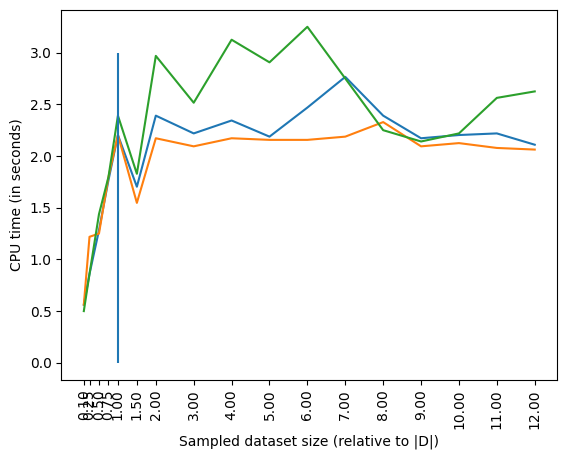

In [ ]:
comp_times_df.T.plot(xlabel="Sampled dataset size (relative to |D|)", ylabel="CPU time (in seconds)", xticks=dataset_fractions, legend=False)
plt.xticks(rotation=90)

plt.vlines(1,0,3)

In [ ]:
print(comp_times_df)

    0.10      0.25     0.50      0.75      1.00      1.50      2.00   \
0  0.5625  0.859375  1.28125  1.765625  2.203125  1.703125  2.390625   
1  0.5625  1.218750  1.25000  1.796875  2.203125  1.546875  2.171875   
2  0.5000  0.859375  1.43750  1.796875  2.390625  1.828125  2.968750   

      3.00      4.00     5.00     6.00      7.00      8.00      9.00   \
0  2.218750  2.343750  2.18750  2.46875  2.765625  2.390625  2.171875   
1  2.093750  2.171875  2.15625  2.15625  2.187500  2.328125  2.093750   
2  2.515625  3.125000  2.90625  3.25000  2.750000  2.250000  2.140625   

      10.00     11.00     12.00  
0  2.203125  2.218750  2.109375  
1  2.125000  2.078125  2.062500  
2  2.218750  2.562500  2.625000  


In [ ]:
print(opt._data.get_repetition_descriptor())

[5724, 2820, 4188, 2412, 4188, 4896, 12, 12, 336, 336, 912, 288, 12, 24, 372, 180, 816, 216, 912, 348, 24, 24, 36, 192, 60, 384, 252, 108, 48, 444, 264, 576, 120, 12, 24, 48, 12, 48, 108, 12, 12, 120, 96, 612, 108, 84, 60, 12, 36, 36, 240, 12, 48, 204, 48, 48, 24, 12, 12, 24, 84, 24, 12, 12, 24, 48, 252, 72, 96, 108, 144, 60, 72, 72, 12, 12, 36, 24, 24, 72, 60, 120, 12, 60, 36, 288, 12, 12, 12, 24, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 96, 216, 192, 240, 48, 120, 12, 36, 60, 60, 24, 12, 12, 36, 84, 48, 12, 36, 12, 72, 36, 12, 12, 36, 48, 12, 12, 12, 36, 24, 12, 12, 36, 12, 12, 12, 12, 12, 24, 12, 12, 24, 12, 12, 216, 492, 132, 156, 36, 24, 24, 24, 12, 12, 96, 60, 24, 12, 12, 24, 36, 12, 84, 48, 24, 12, 12, 36, 12, 24, 12, 12, 36, 24, 12, 12, 12, 12, 24, 12, 12, 12, 24, 60, 24, 24, 12, 36, 12, 36, 12, 24, 12, 12, 24, 12, 12, 12, 60, 156, 216, 156, 384, 276, 12, 12, 12, 60, 48, 36, 36, 60, 24, 12, 12, 12, 24, 12, 12, 12, 24, 12, 12, 24, 12, 12, 12, 12, 24, 24, 12, 12, 12, 12, 12, 36, 2